# Librerias

In [47]:
from sklearn.datasets import load_breast_cancer, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Funcion metricas de clasificacion

In [48]:
def metricas_clasificacion(y_true, y_pred, y_score, nombre_modelo):
    exactitud = accuracy_score(y_true = y_true, y_pred= y_pred)
    presicion = precision_score(y_true = y_true, y_pred= y_pred)
    recall = recall_score(y_true = y_true, y_pred= y_pred)
    f1= f1_score(y_true = y_true, y_pred= y_pred)
    roc_auc = roc_auc_score(y_true= y_true, y_score= y_score)

    return pd.DataFrame(data=[[exactitud, presicion, recall, f1, roc_auc]], columns=[["exactitud", "presicion", "recall", "f1", "roc_auc"]], index= [nombre_modelo]).T

* Exactitud: Predicciones correctas (VP + VN) / total de predicciones (VP + VN + FP + FN)
* Exactitud: mide qué porcentaje de todas las predicciones fueron correctas, tanto positivas como negativas
* Presicion: Predicciones correctas positivas (VP) / Predicciones correctas positivas + Predicciones falsas positivas (VP + FP)
* Presicion: Cuando digo que es positivo, ¿qué tan seguido acierto?
* Recall: Predicciones correctas positivas (VP) / Predicciones correctas positivas + Predicciones Falsas Negatiovas (positivas que no fueron detectadas) (VP + FN)
* Recall: De todos los positivos que existían, ¿cuántos encontré?
* f1: 2 * (presicion * recall) / (presicion + recall)
* f1: Mide que tan equilibrado y armonico es la precicion con el recall

# Naïve Bayes Gaussiano

## Datos

In [49]:
datos = load_breast_cancer()
x= datos.data
y= datos.target

### Division de datos

In [50]:
x_entrenamiento, x_validacion, y_entrenamiento, y_validacion = train_test_split(x, y, test_size=0.2, random_state=24)

## Entrenamiento del modelo

In [51]:
modelo = GaussianNB()
modelo.fit(X= x_entrenamiento, y= y_entrenamiento)
y_predicciones = modelo.predict(x_validacion)
y_proba = modelo.predict_proba(X= x_validacion)[:, 1]
print(accuracy_score(y_true= y_validacion, y_pred= y_predicciones))

0.9210526315789473


In [52]:
metricas= metricas_clasificacion(y_true= y_validacion, y_pred=y_predicciones, y_score=y_proba, nombre_modelo= "GaussianNB")
metricas

,GaussianNB
exactitud,0.921053
presicion,0.944444
recall,0.931507
f1,0.937931
roc_auc,0.983963


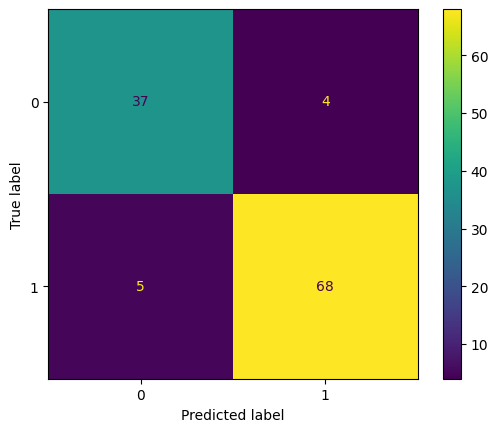

In [53]:
matriz_confusion= confusion_matrix(y_true= y_validacion, y_pred= y_predicciones)
matriz= ConfusionMatrixDisplay(confusion_matrix= matriz_confusion)
matriz.plot()

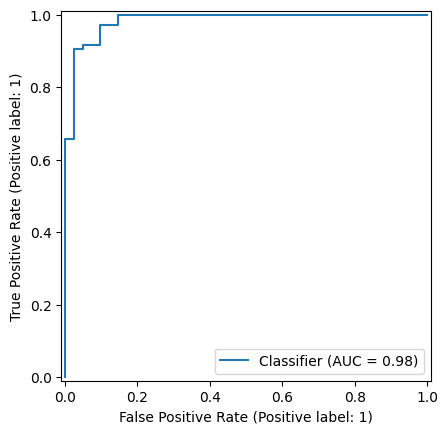

In [54]:
RocCurveDisplay.from_predictions(y_true= y_validacion, y_score= y_proba)

# Naïve Bayes Multinomial

## Datos

In [55]:
categorias = ["sci.space", "rec.sport.baseball"]
datos = fetch_20newsgroups(subset= "train", categories= categorias)

vectorizador = CountVectorizer(binary= True)
x_2= vectorizador.fit_transform(datos.data)
y_2= datos.target

### Division de datos

In [56]:
x_2_entrenamiento, x_2_validacion, y_2_entrenamiento, y_2_validacion = train_test_split(x_2, y_2, test_size=0.3, random_state=24)

## Entrenamiento del modelo

In [57]:
modelo_2 = MultinomialNB()
modelo_2.fit(X= x_2_entrenamiento, y= y_2_entrenamiento)
y_2_predicciones = modelo_2.predict(x_2_validacion)
y_2_proba = modelo_2.predict_proba(X= x_2_validacion)[:, 1]
print(accuracy_score(y_true= y_2_validacion, y_pred= y_2_predicciones))

0.9943977591036415


Metricas

In [58]:
metricas_2= metricas_clasificacion(y_true= y_2_validacion, y_pred=y_2_predicciones, y_score=y_2_proba, nombre_modelo= "MultinomialNB")
metricas_2

,MultinomialNB
exactitud,0.994398
presicion,1.000000
recall,0.988235
f1,0.994083
roc_auc,0.997924


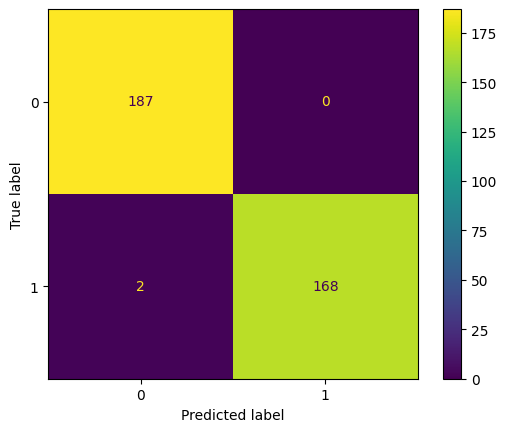

In [59]:
matriz_confusion_2 = confusion_matrix(y_pred= y_2_predicciones, y_true= y_2_validacion)
matriz_2 = ConfusionMatrixDisplay(confusion_matrix= matriz_confusion_2)
matriz_2.plot()

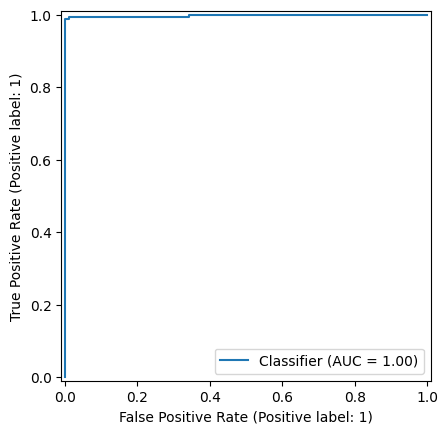

In [60]:
RocCurveDisplay.from_predictions(y_true= y_2_validacion, y_score= y_2_proba)

# Naïve Bayes Bernoull

## Datos

In [61]:
categorias = ["sci.space", "rec.sport.baseball"]
datos = fetch_20newsgroups(subset= "train", categories= categorias)

vectorizador = CountVectorizer(binary= True)
x_3= vectorizador.fit_transform(datos.data)
y_3= datos.target

### Division de datos

In [62]:
x_3_entrenamiento, x_3_validacion, y_3_entrenamiento, y_3_validacion = train_test_split(x_2, y_2, test_size=0.3, random_state=24)

## Entrenamiento del modelo

In [63]:
modelo_3 = BernoulliNB()
modelo_3.fit(X= x_3_entrenamiento, y= y_3_entrenamiento)
y_3_predicciones = modelo_3.predict(x_3_validacion)
y_3_proba = modelo_3.predict_proba(X= x_3_validacion)[:, 1]
print(accuracy_score(y_true= y_3_validacion, y_pred= y_3_predicciones))

0.9159663865546218


Metricas


In [64]:
metricas_3= metricas_clasificacion(y_true= y_3_validacion, y_pred=y_3_predicciones, y_score=y_3_proba, nombre_modelo= "BernoulliNB")
metricas_3

,BernoulliNB
exactitud,0.915966
presicion,0.992958
recall,0.829412
f1,0.903846
roc_auc,0.998868


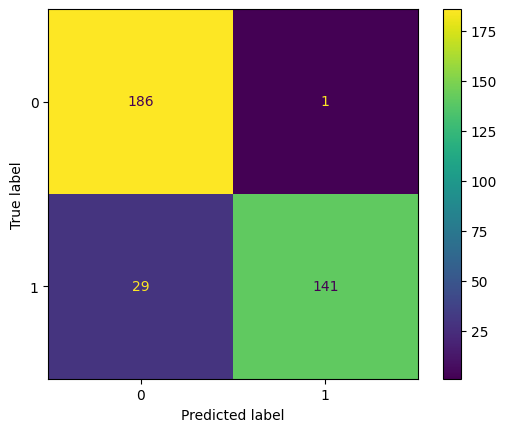

In [65]:
matriz_confusion_3 = confusion_matrix(y_pred= y_3_predicciones, y_true= y_3_validacion)
matriz_3 = ConfusionMatrixDisplay(confusion_matrix= matriz_confusion_3)
matriz_3.plot()

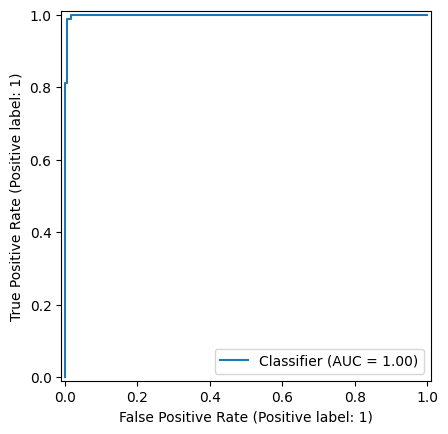

In [66]:
RocCurveDisplay.from_predictions(y_true= y_3_validacion, y_score= y_3_proba)

In [67]:
tabla_metricas = pd.concat(objs= [metricas, metricas_2, metricas_3], axis= 1 )
tabla_metricas

,GaussianNB,MultinomialNB,BernoulliNB
exactitud,0.921053,0.994398,0.915966
presicion,0.944444,1.000000,0.992958
recall,0.931507,0.988235,0.829412
f1,0.937931,0.994083,0.903846
roc_auc,0.983963,0.997924,0.998868


Podemos observar que de los modelos entrenados el modelo que mejor exactitud presentó fue el multinomial, el modelo que mejor presición presentó fue el multinomial, el modelo que mejor recall presentó fue el multinomial y el modelo que mejor F1 prsentó fue el multinomial, por ultimo el modelo que mejor roc_auc presentó fue el Bernoulli pero con una diferencia minuscula de una centecima. Podemos conclui que en este caso, con estos datos el modelo Multinomial resulta ser mas efectivo que el modelo Bernoulli, no se puede realizar una comparativa exacta con el modelo Gausian ya que sus datos de entrenamiento fueron disintos.